# Brain Tumor Detection using Tensorflow CNN / EfficientNet-B0 

<div style="text-align: center;">
    <img src="https://i.pinimg.com/736x/3b/26/c6/3b26c6e849e256256385850a9820d5e3.jpg" width="500">
    <p><strong>In this notebook I'll tackle one of the most important medical tasks related to computer vision: brain tumour detection and classification, using Tensorflow Convolutional Neural networks (CNN) with and without data augmentation, and more powerful architecture EfficientNet-B0</strong></p>
</div>

## Importing Libraries

In [1]:
import os
import kagglehub
import numpy as np
import pandas as pd
from tqdm import tqdm
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import time

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report,confusion_matrix

2025-07-12 12:35:45.445749: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752323745.639593      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752323745.699457      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
from tensorflow.keras.applications import EfficientNetB0, ResNet101 

In [3]:
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.4/997.4 kB 22.3 MB/s eta 0:00:00


In [4]:
import visualkeras
from tensorflow.keras.utils import plot_model

## Data Loading

In [5]:
# Download latest version
path = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")

In [6]:
path

'/kaggle/input/brain-tumor-classification-mri'

In [7]:
X_train = []
y_train = []
labels = ['glioma_tumor','no_tumor','meningioma_tumor','pituitary_tumor']

image_size = 256
for i in labels:
  folderPath = os.path.join(f'{path}/Training', i)
  for j in tqdm(os.listdir(folderPath)):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size, image_size))
        X_train.append(img)
        y_train.append(i)

for i in labels:
  folderPath = os.path.join(f'{path}/Testing', i)
  for j in tqdm(os.listdir(folderPath)):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size, image_size))
        X_train.append(img)
        y_train.append(i)


100%|██████████| 74/74 [00:00<00:00, 80.25it/s]


In [8]:
X_train = np.array(X_train)
y_train = np.array(y_train)

In [9]:
y_train

array(['glioma_tumor', 'glioma_tumor', 'glioma_tumor', ...,
       'pituitary_tumor', 'pituitary_tumor', 'pituitary_tumor'],
      dtype='<U16')

## Visualizatioin

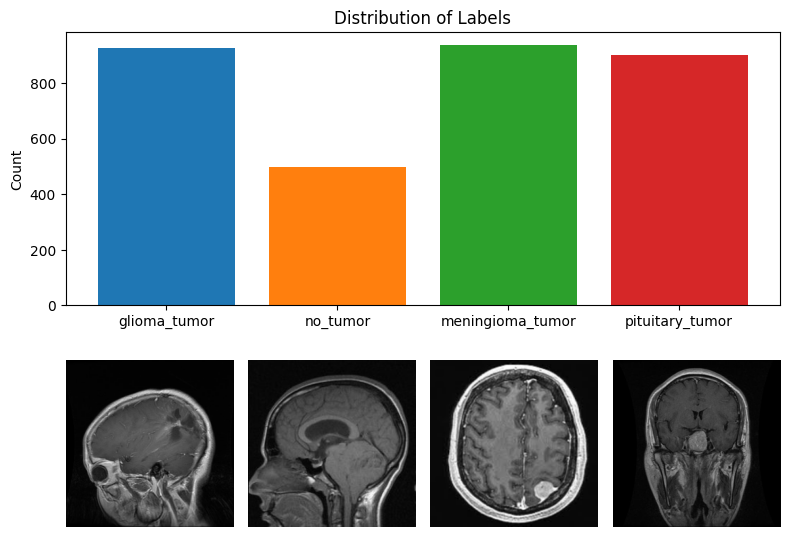

In [10]:
label_counts = {label: np.sum(y_train == label) for label in labels}

plt.figure(figsize=(8, 6))

colors = ["C0", "C1", "C2", "C3"]

# Plot the histogram
plt.subplot(2, 1, 1)
bars = plt.bar(label_counts.keys(), label_counts.values(), color=colors)

# plt.xlabel('Labels')
plt.ylabel('Count')
plt.title('Distribution of Labels')

# Plot sample images from each label
k = 0
for i in labels:
    j = 0
    while True:
        if y_train[j] == i:
            plt.subplot(2, 4, k + 5)
            plt.imshow(X_train[j])
            plt.axis('off')
            k += 1
            break
        j += 1

plt.tight_layout()
plt.show()

## Content Description
1. Glioma: Cancerous brain tumors in glial cells.
2. Meningioma: Non-cancerous tumors originating from the meninges.
3. No Tumor: Normal brain scans without detectable tumors.
4. Pituitary: Tumors affecting the pituitary gland, which can be cancerous or non-cancerous.

## Data augmentation

In [11]:
datagen = ImageDataGenerator(
    rotation_range=20, # Rotate images by ±20 degrees
    width_shift_range=0.1, # Shift width by 10% of original size
    height_shift_range=0.1, # Shift height by 10% of the original size
    zoom_range=0.1, # Zoom in/out by 10%
    horizontal_flip=False, # Horizontal reflection prohibited
    vertical_flip=False,  # Vertical reflection is prohibited
    fill_mode='nearest') # Fill empty pixels with nearest values

datagen.fit(X_train)

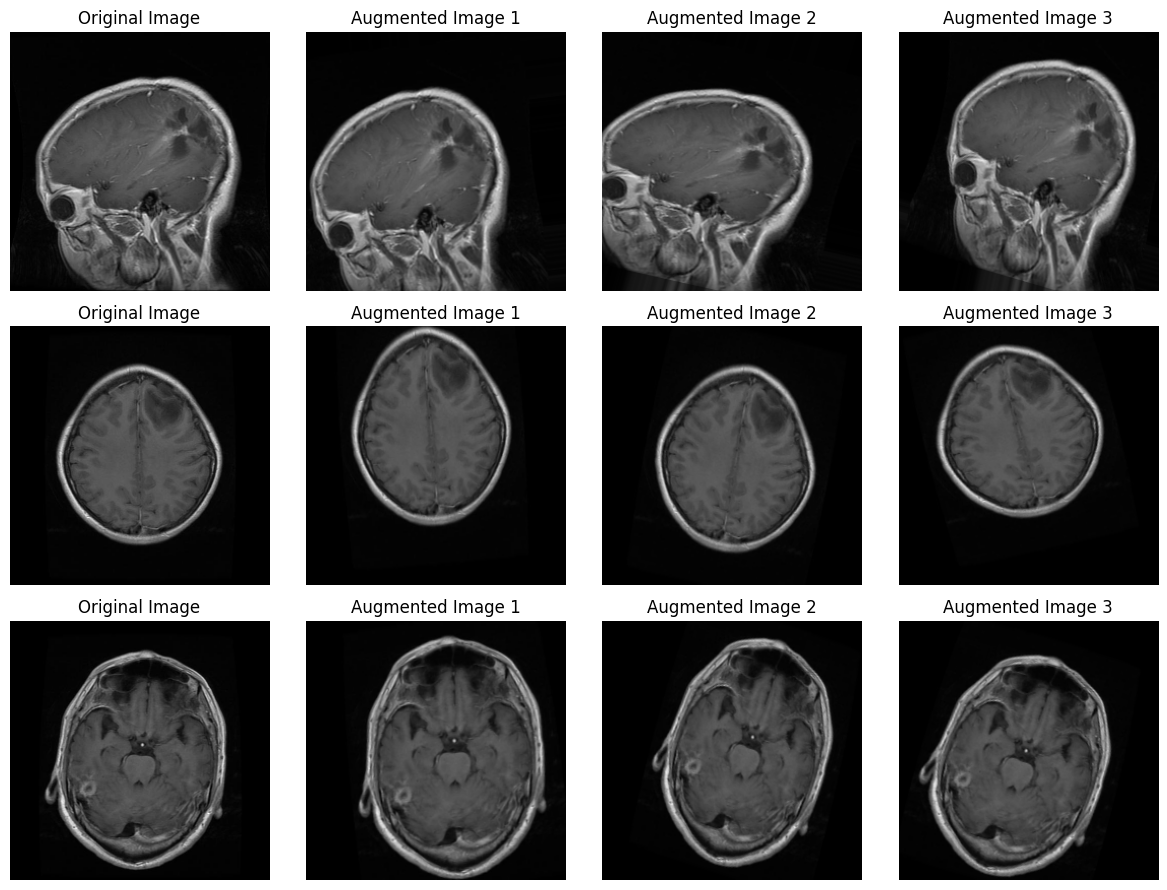

In [12]:
def visualize_augmented_images(image_generator, num_samples, num_augmented_images):
    augmented_images = []
    for sample in X_train[:num_samples]:

        # Create a list to store augmented versions of a sample
        augmented_samples = [sample]
        for _ in range(num_augmented_images):
            augmented_samples.append(image_generator.random_transform(sample))
        augmented_images.append(augmented_samples)

    # Plot original and augmented images
    fig, axes = plt.subplots(num_samples, num_augmented_images + 1, figsize=( 12, num_samples * 3))
    for i, sample in enumerate(augmented_images):
        for j, image in enumerate(sample):
            axes[i,j].imshow(image)
            if j == 0:
                axes[i, j].set_title('Original Image')
            else:
                axes[i,j].set_title(f'Augmented Image {j}')
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()

#Visualize augmented images to see how it works
visualize_augmented_images(datagen, num_samples=3, num_augmented_images=3)

## Data Preparation

In [13]:
# Convert y_train labels to one-hot encoded format using pandas
y_train = np.array(pd.get_dummies(y_train))

In [14]:
#Split the dataset into training, testing and validation sets
X_train,X_test,y_train,y_test = train_test_split(X_train,y_train, test_size=0.1,random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

print(f'X_train shape: {(X_train).shape}\n'
      f'y_train shape: {(y_train).shape}\n'
      f'X_test shape: {(X_test).shape}\n'
      f'y_test shape: {(y_test).shape}\n'
      f'X_valid shape: {(X_valid).shape}\n'
      f'y_validshape: {(y_valid).shape}')

X_train shape: (2643, 256, 256, 3)
y_train shape: (2643, 4)
X_test shape: (327, 256, 256, 3)
y_test shape: (327, 4)
X_valid shape: (294, 256, 256, 3)
y_validshape: (294, 4)


## Normalization

In [15]:
# Normalize pixel values of training images to the range [0,1]
X_train_norm = X_train / 255
X_test_norm = X_test / 255
X_valid_norm = X_valid / 255

print(f"Maximum and Minimum pixel value after normalization: {X_train_norm.max()} - {X_train_norm.min()}")

Maximum and Minimum pixel value after normalization: 1.0 - 0.0


In [16]:
input_shape = (256, 256, 3)

## Model with Data Augmentation

In [17]:
# Define the model
model_with_aug = Sequential(
    [
        Input(input_shape),
        Conv2D(16, kernel_size=(5,5), activation='relu', padding='same'),
        MaxPooling2D(),
        Dropout(0.2),

        Conv2D(16, kernel_size=(5,5), activation='relu', padding='same'),
        MaxPooling2D(),
        Dropout(0.2),

        Conv2D(32, kernel_size=(3,3), activation='relu', padding='same'),
        MaxPooling2D(),
        Dropout(0.2),

        Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'),
        MaxPooling2D(),
        Dropout(0.3),
        
        
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(4, activation='softmax')  # the Softmax function works for multiclass classification problems
                                            # and the Sigmoid function is a better option for binary-class problems.
    ]
)

I0000 00:00:1752323804.527378      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1752323804.527974      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [18]:
model_with_aug.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])

model_with_aug.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 256, 256, 16)        │           1,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 128, 128, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128, 128, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 128, 128, 16)        │           6,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 64, 64, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64, 64, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 64, 64, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       2,097,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,128,564 (8.12 MB)

 Trainable params: 2,128,564 (8.12 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.11/dist-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


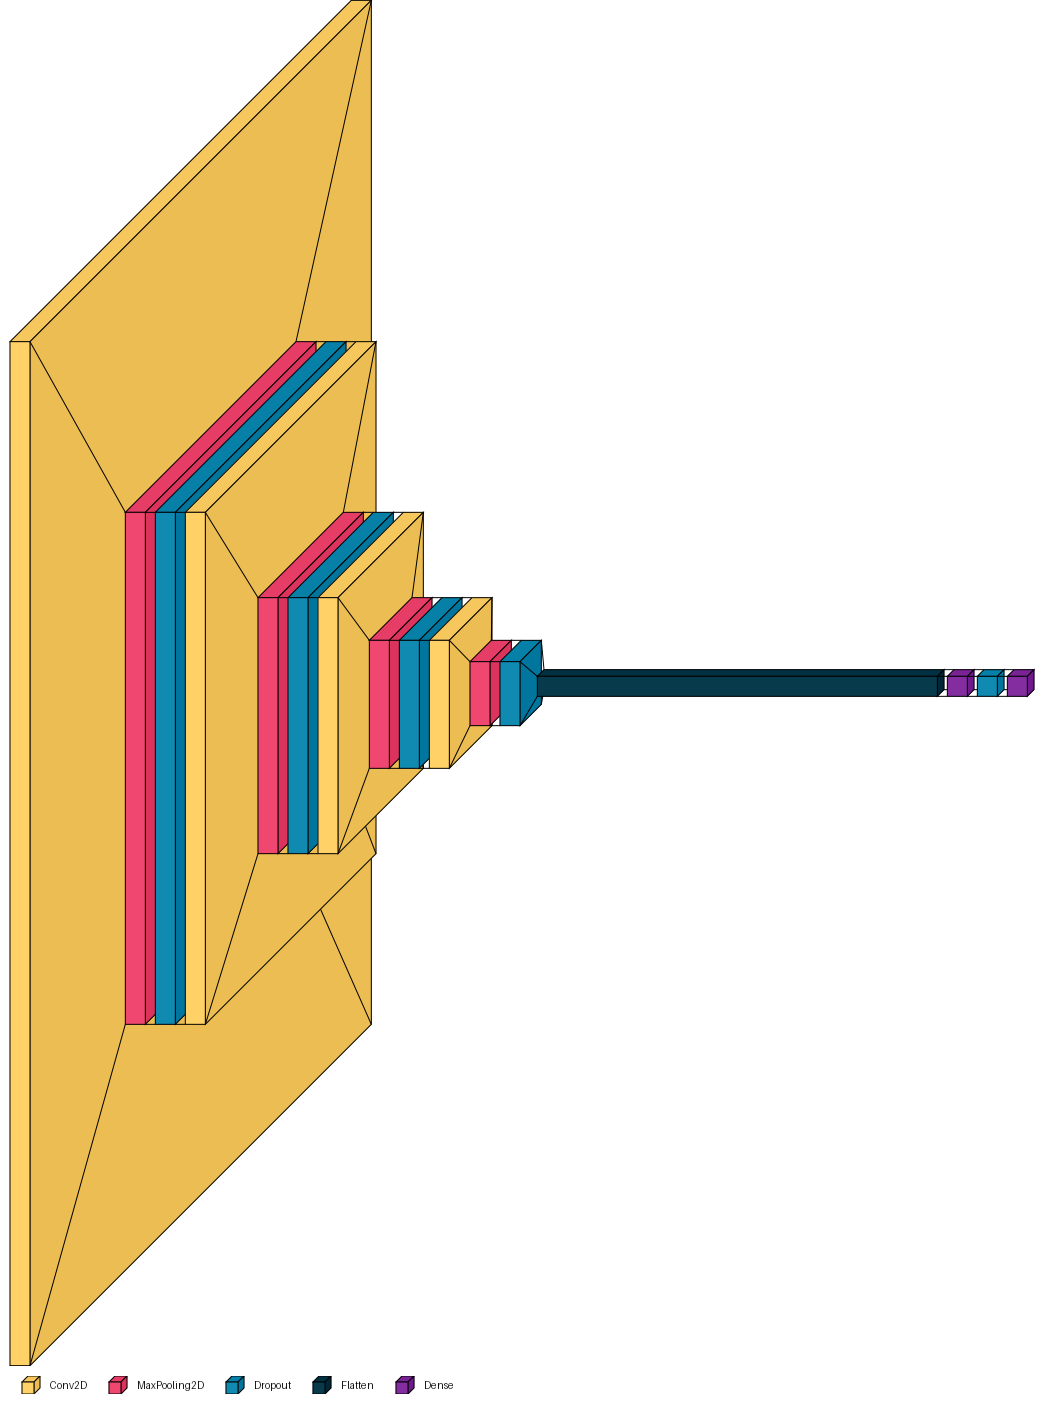

In [19]:
visualkeras.layered_view(model_with_aug, legend=True) # without custom font
from PIL import ImageFont
visualkeras.layered_view(model_with_aug, legend=True) 

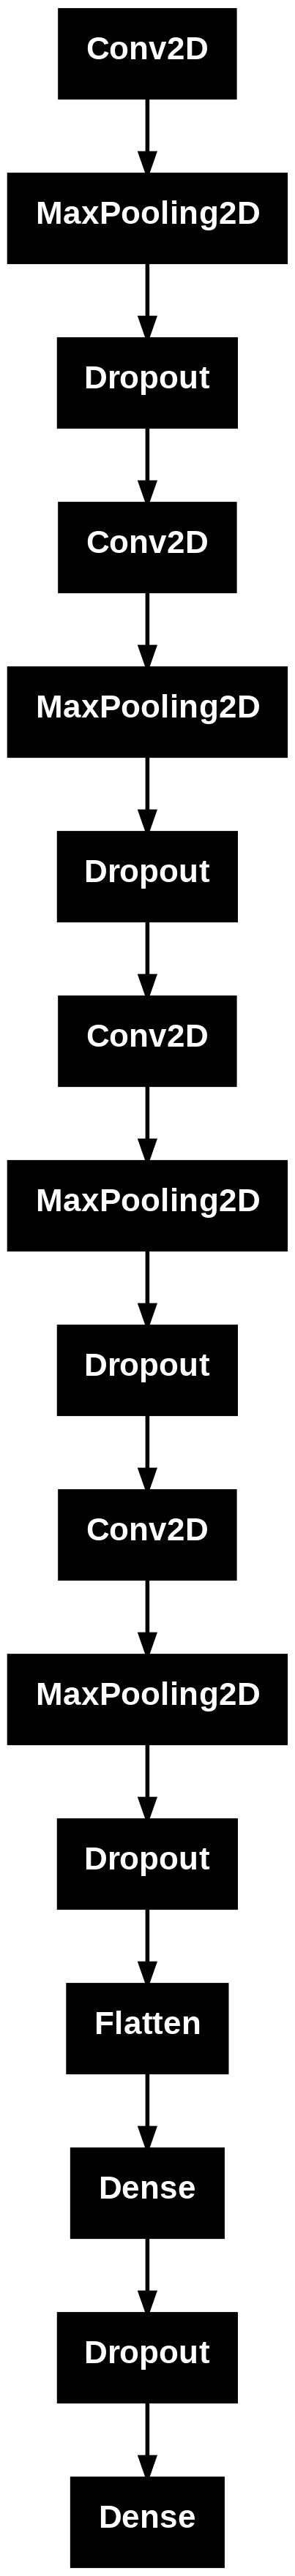

In [20]:
plot_model(model_with_aug)

In [21]:
start_time = time.time()

history_with_aug = model_with_aug.fit(datagen.flow(X_train, y_train, batch_size=64),
                    validation_data=(X_valid, y_valid),
                    epochs=45, verbose=1)

end_time = time.time()

runtime = end_time - start_time
print("Total runtime:", runtime, "seconds")

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/45


I0000 00:00:1752323812.153201      73 service.cc:148] XLA service 0x7a46d020cc00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752323812.154002      73 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1752323812.154023      73 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1752323812.554323      73 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/42 ━━━━━━━━━━━━━━━━━━━━ 8:38 13s/step - accuracy: 0.3906 - loss: 103.3576

I0000 00:00:1752323820.903426      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


42/42 ━━━━━━━━━━━━━━━━━━━━ 51s 929ms/step - accuracy: 0.2947 - loss: 94.7760 - val_accuracy: 0.3878 - val_loss: 1.3467
Epoch 2/45
42/42 ━━━━━━━━━━━━━━━━━━━━ 33s 791ms/step - accuracy: 0.3728 - loss: 1.3325 - val_accuracy: 0.4082 - val_loss: 1.3182
Epoch 3/45
42/42 ━━━━━━━━━━━━━━━━━━━━ 34s 796ms/step - accuracy: 0.4115 - loss: 1.2952 - val_accuracy: 0.4048 - val_loss: 1.3098
Epoch 4/45
42/42 ━━━━━━━━━━━━━━━━━━━━ 34s 797ms/step - accuracy: 0.4065 - loss: 1.2819 - val_accuracy: 0.4286 - val_loss: 1.2875
Epoch 5/45
42/42 ━━━━━━━━━━━━━━━━━━━━ 33s 792ms/step - accuracy: 0.4190 - loss: 1.2665 - val_accuracy: 0.5102 - val_loss: 1.1836
Epoch 6/45
42/42 ━━━━━━━━━━━━━━━━━━━━ 33s 791ms/step - accuracy: 0.4192 - loss: 1.2374 - val_accuracy: 0.4490 - val_loss: 1.2558
Epoch 7/45
42/42 ━━━━━━━━━━━━━━━━━━━━ 33s 790ms/step - accuracy: 0.4667 - loss: 1.2020 - val_accuracy: 0.3810 - val_loss: 1.2307
Epoch 8/45
42/42 ━━━━━━━━━━━━━━━━━━━━ 33s 792ms/step - accuracy: 0.4378 - loss: 1.2109 - val_accuracy: 0.51

### Plotting training and validation loss and accuracy

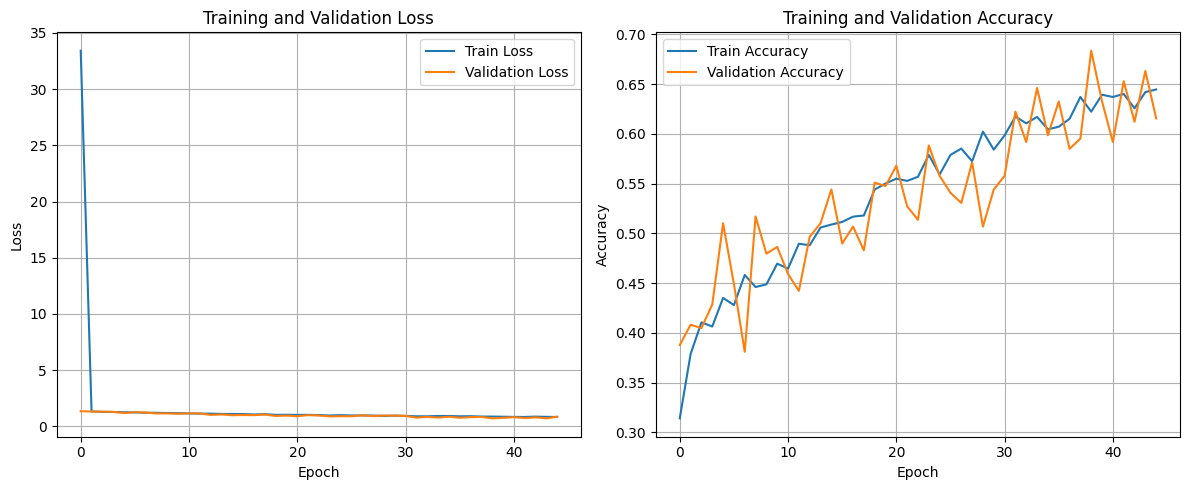

In [22]:
# Plotting training and validation loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_with_aug.history['loss'], label='Train Loss')
plt.plot(history_with_aug.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history_with_aug.history['accuracy'], label='Train Accuracy')
plt.plot(history_with_aug.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

### Saving model

In [23]:
model_with_aug.save("my_model_aug.keras")

In [24]:
model_with_aug.save_weights("my_model_aug.weights.h5")

In [25]:
model_with_aug = tf.keras.models.load_model("my_model_aug.keras")

### Confusion Matrix

83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step


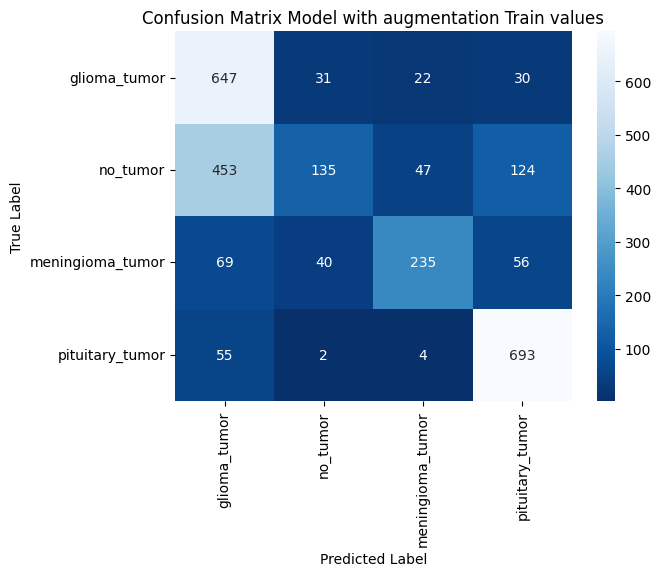

In [26]:
y_true = np.argmax(y_train, axis=1)
y_pred = np.argmax(model_with_aug.predict(X_train), axis=1)

heatmap = sns.heatmap(confusion_matrix(y_true,y_pred), annot=True, fmt='d', cmap='Blues_r',
                      xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix Model with augmentation Train values')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step


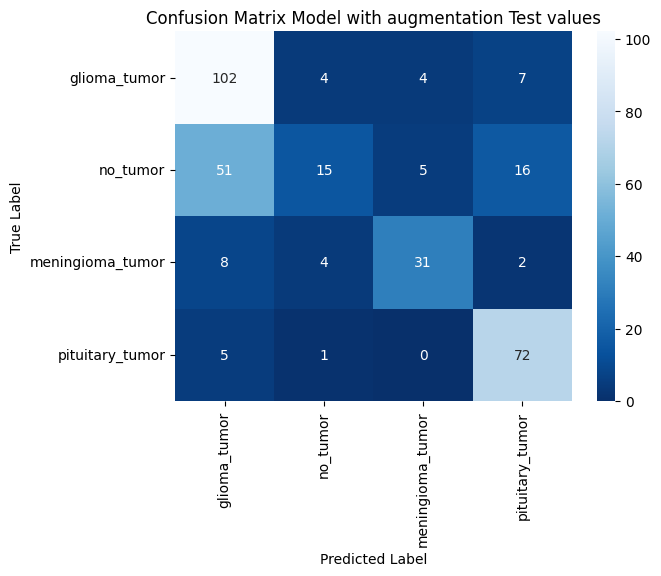

In [27]:
y_true_test = np.argmax(y_test, axis=1)
y_pred_test = np.argmax(model_with_aug.predict(X_test), axis=1)

heatmap = sns.heatmap(confusion_matrix(y_true_test,y_pred_test), annot=True, fmt='d', cmap='Blues_r',
                      xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix Model with augmentation Test values')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Classification Report

In [28]:
# 0 - Glioma Tumor
# 1 - No Tumor
# 2 - Meningioma Tumor
# 3 - Pituitary Tumor
print(classification_report(y_true_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.61      0.87      0.72       117
           1       0.62      0.17      0.27        87
           2       0.78      0.69      0.73        45
           3       0.74      0.92      0.82        78

    accuracy                           0.67       327
   macro avg       0.69      0.66      0.64       327
weighted avg       0.67      0.67      0.63       327



### Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step
Predicted label: pituitary_tumor 
Actual label: pituitary_tumor 
Confidence: 94.89%



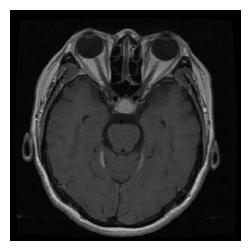

In [29]:
random_index = np.random.randint(0, len(X_test))
random_img = X_test[random_index]
predictions = model_with_aug.predict(random_img.reshape(1, 256, 256, 3))  # Reshape and preprocess the image

# Interpret the model's predictions
predicted_class = np.argmax(predictions)  # Get the index of the class with the highest probability
predicted_label = labels[predicted_class]  # Convert class to label
confidence = predictions[0][predicted_class]

actual_index = y_test[random_index]  # Get the one-hot encoded actual class
actual_class = np.argmax(actual_index)
actual_label = labels[actual_class]

# Display the image and prediction information
print(f"\033[94mPredicted label: {predicted_label}\033[0m \n\033[92mActual label: {actual_label}\033[0m \n\033[93mConfidence: {confidence*100:.2f}%\033[0m\n")
plt.figure(figsize = (3,3))
plt.imshow(random_img)
plt.axis('off')
plt.show()

## Model Withought Augmentation

In [30]:
model = Sequential([
    Input(shape=(256, 256, 3)),

    Conv2D(32, kernel_size=(5,5), activation='relu', padding='same'),
    MaxPooling2D(),
    Dropout(0.15),

    Conv2D(32, kernel_size=(5,5), activation='relu', padding='same'),
    MaxPooling2D(),
    Dropout(0.15),

    Conv2D(32, kernel_size=(3,3), activation='relu', padding='same'),
    MaxPooling2D(),
    Dropout(0.15),

    Conv2D(64, kernel_size=(2,2), activation='relu', padding='same'),
    MaxPooling2D(),
    Dropout(0.15),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.45),
    Dense(4, activation='softmax')
])

In [31]:
model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 256, 256, 32)        │           2,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 128, 128, 32)        │          25,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 64, 64, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 32, 32, 64)          │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       2,097,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,143,364 (8.18 MB)

 Trainable params: 2,143,364 (8.18 MB)

 Non-trainable params: 0 (0.00 B)

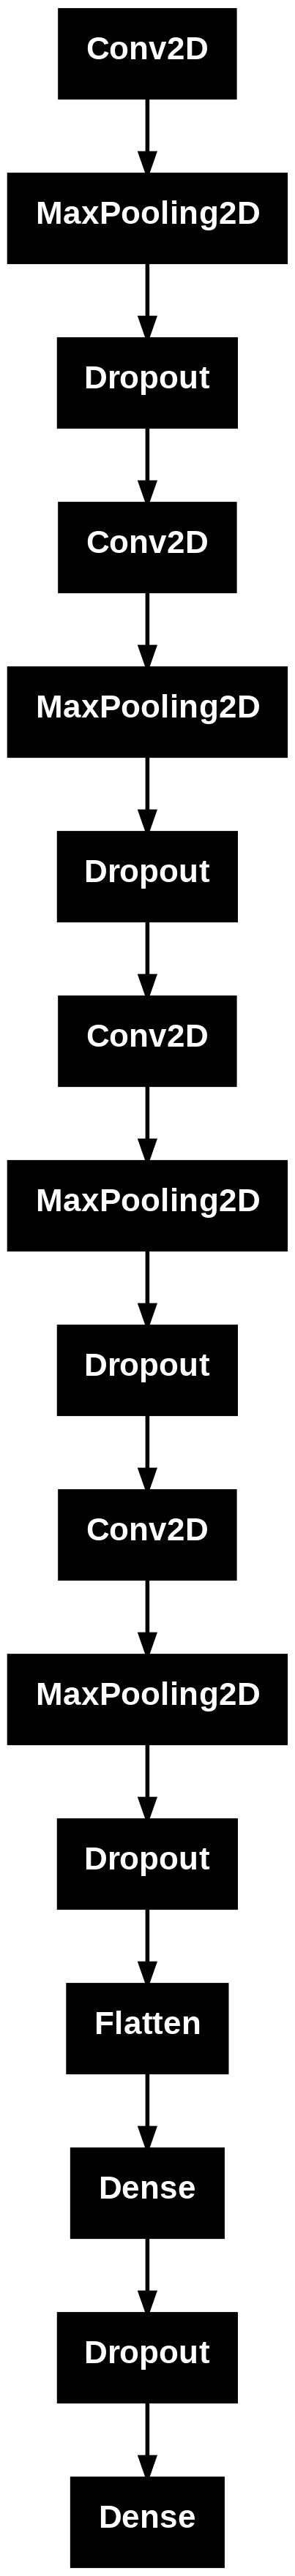

In [32]:
plot_model(model)

In [33]:
start_time = time.time()

history = model.fit(X_train,y_train,validation_data=(X_valid, y_valid), epochs =45, verbose=1, batch_size=64)

end_time = time.time()

runtime = end_time - start_time
print("Total runtime:", runtime, "seconds")

Epoch 1/45


2025-07-12 13:02:30.872714: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng0{} for conv (f32[32,3,5,5]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,3,256,256]{3,2,1,0}, f32[64,32,256,256]{3,2,1,0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-07-12 13:02:31.503164: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.630567442s
Trying algorithm eng0{} for conv (f32[32,3,5,5]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,3,256,256]{3,2,1,0}, f32[64,32,256,256]{3,2,1,0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"cudnn_conv_backend_config":{"activat

42/42 ━━━━━━━━━━━━━━━━━━━━ 34s 415ms/step - accuracy: 0.3237 - loss: 37.0899 - val_accuracy: 0.3027 - val_loss: 1.3846
Epoch 2/45
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.4025 - loss: 1.3389 - val_accuracy: 0.4014 - val_loss: 1.2669
Epoch 3/45
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.4934 - loss: 1.1855 - val_accuracy: 0.4864 - val_loss: 1.1150
Epoch 4/45
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.5467 - loss: 1.0424 - val_accuracy: 0.5306 - val_loss: 0.9845
Epoch 5/45
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.5875 - loss: 0.9792 - val_accuracy: 0.5986 - val_loss: 0.9520
Epoch 6/45
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.6527 - loss: 0.8426 - val_accuracy: 0.6395 - val_loss: 0.9010
Epoch 7/45
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.6648 - loss: 0.7859 - val_accuracy: 0.6599 - val_loss: 0.8042
Epoch 8/45
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.6696 - loss: 0.7580 - val_accuracy: 0.7177 - va

### Plotting training and validation loss and accuracy

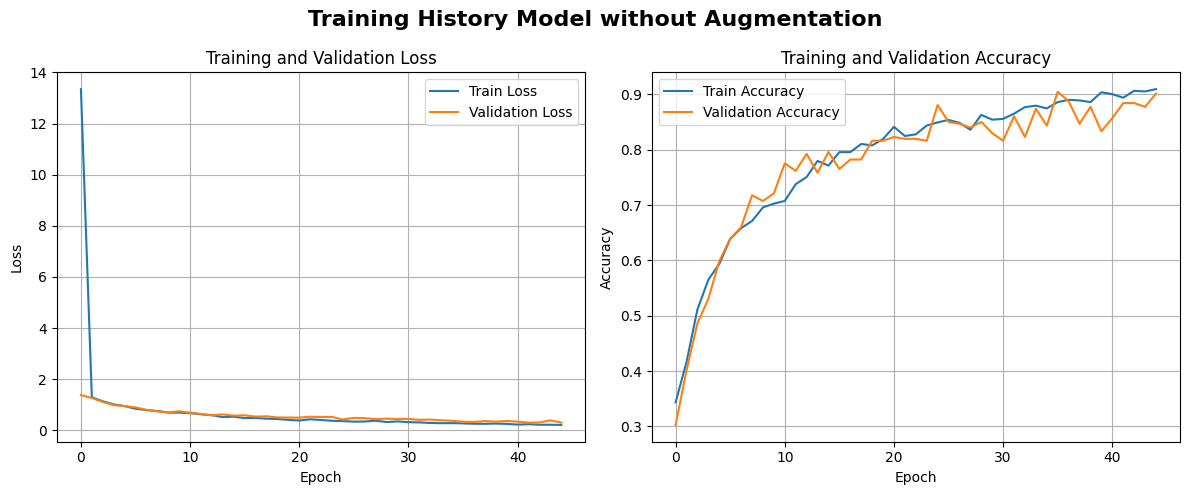

In [34]:
# Plotting training and validation loss
plt.figure(figsize=(12, 5))

plt.suptitle('Training History Model without Augmentation', fontsize=16, fontweight='bold')

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

### Saving model

In [35]:
model.save("my_model_without_aug.keras")

In [36]:
model.save_weights("my_model_without_aug.weights.h5")

In [37]:
model = tf.keras.models.load_model("my_model_without_aug.keras")

### Consufion Matrix

83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step


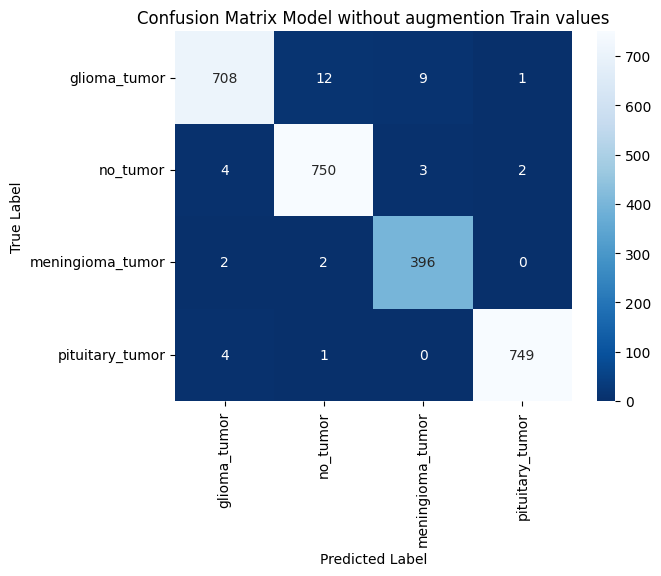

In [38]:
y_true = np.argmax(y_train, axis=1)
y_pred = np.argmax(model.predict(X_train), axis=1) 

heatmap = sns.heatmap(confusion_matrix(y_true,y_pred), annot=True, fmt='d', cmap='Blues_r',
                      xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix Model without augmention Train values')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step


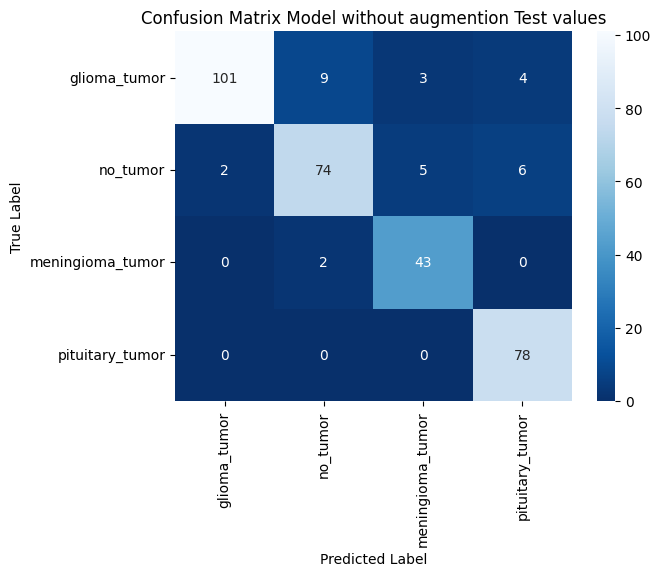

In [39]:
y_true_test = np.argmax(y_test, axis=1)
y_pred_test = np.argmax(model.predict(X_test), axis=1) 

heatmap = sns.heatmap(confusion_matrix(y_true_test,y_pred_test), annot=True, fmt='d', cmap='Blues_r',
                      xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix Model without augmention Test values')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Precision: Determines the accuracy of positive predictions by indicating how many of the predicted positive instances are actually positive.

Recall: This metric measures the model's ability to correctly identify all relevant instances, indicating how many actual positive instances were correctly predicted.

F1-score: Represents the harmonic mean of precision and recall, providing a balance between the two, which is especially useful when classes are imbalanced.

Support: Indicates the number of actual occurrences of each class in the dataset, which provides context for calculating precision, recall, and F1 score.

Accuracy: Indicates the overall correctness of the model's predictions by displaying the proportion of correctly predicted instances to the total number of instances.

Macro Avg: Calculates the average precision, recall, and F1-score for all classes, treating each class equally regardless of class imbalance.

Weighted Avg: Calculates the weighted average of precision, recall, and F1-score, with each class's score weighted by its support, providing a more accurate picture of overall model performance, particularly when classes are imbalanced.

### Classification Report

In [40]:
# 0 - Glioma Tumor
# 1 - No Tumor
# 2 - Meningioma Tumor
# 3 - Pituitary Tumor
print(classification_report(y_true_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.98      0.86      0.92       117
           1       0.87      0.85      0.86        87
           2       0.84      0.96      0.90        45
           3       0.89      1.00      0.94        78

    accuracy                           0.91       327
   macro avg       0.90      0.92      0.90       327
weighted avg       0.91      0.91      0.90       327



In [41]:
model = tf.keras.models.load_model("my_model_without_aug.keras")

### Multiple Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


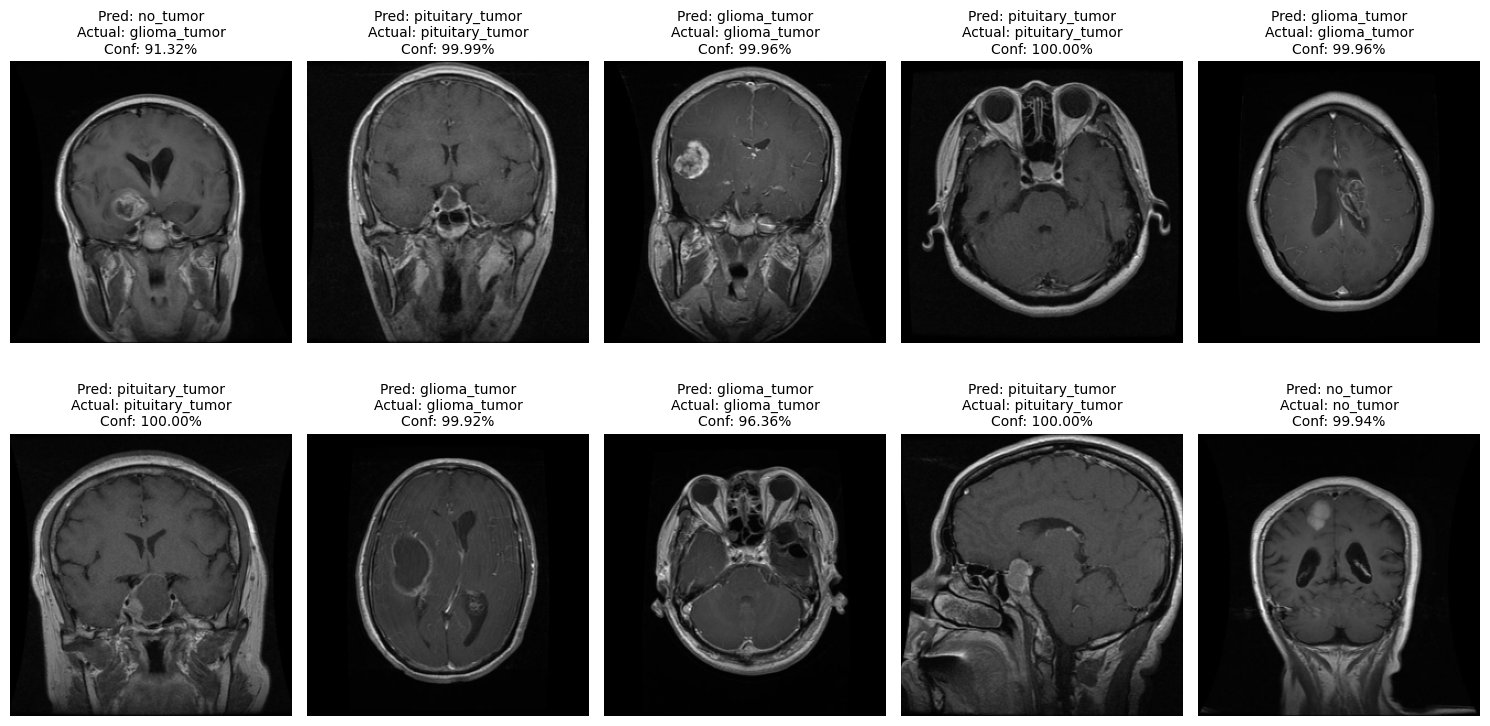


Image 1:
Predicted label: no_tumor
Actual label: glioma_tumor
Confidence: 91.32%

Image 2:
Predicted label: pituitary_tumor
Actual label: pituitary_tumor
Confidence: 99.99%

Image 3:
Predicted label: glioma_tumor
Actual label: glioma_tumor
Confidence: 99.96%

Image 4:
Predicted label: pituitary_tumor
Actual label: pituitary_tumor
Confidence: 100.00%

Image 5:
Predicted label: glioma_tumor
Actual label: glioma_tumor
Confidence: 99.96%

Image 6:
Predicted label: pituitary_tumor
Actual label: pituitary_tumor
Confidence: 100.00%

Image 7:
Predicted label: glioma_tumor
Actual label: glioma_tumor
Confidence: 99.92%

Image 8:
Predicted label: glioma_tumor
Actual label: glioma_tumor
Confidence: 96.36%

Image 9:
Predicted label: pituitary_tumor
Actual label: pituitary_tumor
Confidence: 100.00%

Image 10:
Predicted label: no_tumor
Actual label: no_tumor
Confidence: 99.94%


In [42]:
random_indexes = np.random.randint(0, len(X_test), 10)
random_imgs = X_test[random_indexes]
predictions = [model.predict(random_img.reshape(1, 256, 256, 3)) for random_img in random_imgs]  # Reshape and preprocess the image

# Interpret the model's predictions
predicted_classes = [np.argmax(prediction) for prediction in predictions]  # Get the index of the class with the highest probability
predicted_labels = [labels[predicted_class] for predicted_class in predicted_classes]  # Convert class to label
confidences = [prediction[0][predicted_class] for prediction, predicted_class in zip(predictions, predicted_classes)]

actual_indexes = [y_test[random_index] for random_index in random_indexes]  # Get the one-hot encoded actual class
actual_classes = [np.argmax(actual_index) for actual_index in actual_indexes]
actual_labels = [labels[actual_class] for actual_class in actual_classes]

plt.figure(figsize=(15, 8))
for i in range(10):
    plt.subplot(2, 5, i + 1)  # 2 rows, 5 columns
    plt.imshow(random_imgs[i])
    plt.title(f"Pred: {predicted_labels[i]}\nActual: {actual_labels[i]}\nConf: {confidences[i]*100:.2f}%",
              fontsize=10, color='black')
    plt.axis('off')
plt.tight_layout()
plt.show()

for i in range(10):
    print(f"\nImage {i+1}:")
    print(f"\033[94mPredicted label: {predicted_labels[i]}\033[0m")
    print(f"\033[92mActual label: {actual_labels[i]}\033[0m")
    print(f"\033[93mConfidence: {confidences[i]*100:.2f}%\033[0m")

## Transfer Learning

### EfficientNetB0
The EfficientNet architecture is represented by a set of ready-to-use models. The choice depends on the required accuracy, available training resources, and input image resolution. Models are labelled from B0 (simplest) to B7 (most powerful).

Graph showing the dependence of the accuracy of different models on the number of parameters

<img src="https://habrastorage.org/r/w1560/getpro/habr/upload_files/f37/d94/853/f37d94853cbd60999b420ee88ffcb479.png" width="600">
<img src="https://habrastorage.org/r/w1560/getpro/habr/upload_files/998/d99/1c7/998d991c728ea168111e48fdfeff8bb4.png" width="600">
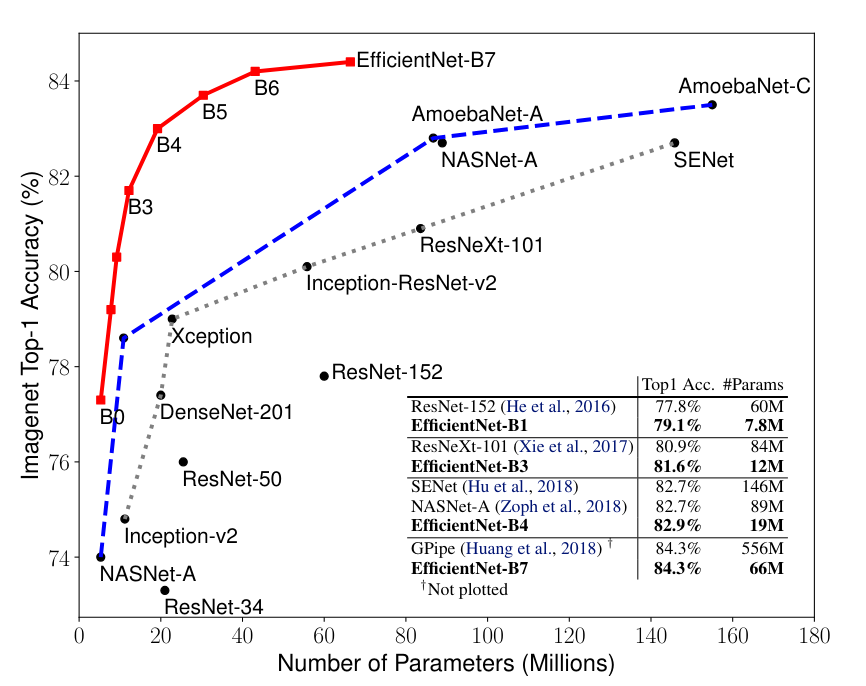

I'll use **EfficientNet-B0** architecture with the weights from **ImageNet** dataset. EfficientNet-B0 is trained on the ImageNet dataset and can classify images into 1000 object categories. The point is to re-use the weights from the pre-trained models downloading and using directly or integrating into a new model that we'll do.

The include_top parameter is set to False, so the network does not include he top layer/ output layer. We have a possibility to add our own output layer depending on our needs. (4 values)

In [43]:
base_model = EfficientNetB0(include_top = False, weights = "imagenet", input_shape = (256, 256, 3))

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [44]:
x = base_model.output

In [45]:
x = GlobalAveragePooling2D()(x)

In [46]:
x = Dropout(0.5)(x)

In [47]:
x = Dense(4, activation="softmax")(x)

In [48]:
model_eff = Model(inputs=base_model.input, outputs=x)

In [49]:
# model_eff.summary()

In [50]:
# plot_model(model_eff)

/usr/local/lib/python3.11/dist-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")




In [51]:
visualkeras.layered_view(model_eff)

In [52]:
# visualkeras.layered_view(model_eff, legend=True) # without custom font
# from PIL import ImageFont
# visualkeras.layered_view(model_eff, legend=True) 

In [53]:
# visualkeras.layered_view(model_eff, legend=True, draw_volume=False)

In [54]:
# visualkeras.layered_view(model_eff, legend=True, draw_volume=False,spacing=30)

In [55]:
model_eff.compile(loss='categorical_crossentropy',optimizer = 'Adam', metrics= ['accuracy'])

In [56]:
tensorboard = TensorBoard(log_dir = 'logs')
checkpoint = ModelCheckpoint("effnet.keras",monitor="val_accuracy",save_best_only=True,mode="auto",verbose=1)
reduce_lr = ReduceLROnPlateau(monitor = 'val_accuracy', factor = 0.3, patience = 2, min_delta = 0.001,
                              mode='auto',verbose=1)

In [57]:
history_eff = model_eff.fit(X_train, y_train, validation_split=0.1, epochs=12, verbose=1, batch_size=32, callbacks=[tensorboard,checkpoint,reduce_lr])

Epoch 1/12


E0000 00:00:1752325657.743788      72 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752325657.929311      72 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752325665.314694      72 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752325665.460220      72 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752325665.975154      72 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

74/75 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7312 - loss: 0.6713

E0000 00:00:1752325706.043880      73 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752325706.193113      73 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752325710.146136      73 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752325710.283462      73 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.7326 - loss: 0.6685

E0000 00:00:1752325737.896711      73 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752325738.044501      73 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from -inf to 0.81132, saving model to effnet.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 145s 750ms/step - accuracy: 0.7339 - loss: 0.6658 - val_accuracy: 0.8113 - val_loss: 0.7168 - learning_rate: 0.0010
Epoch 2/12
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9397 - loss: 0.1848
Epoch 2: val_accuracy improved from 0.81132 to 0.94340, saving model to effnet.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 179ms/step - accuracy: 0.9398 - loss: 0.1847 - val_accuracy: 0.9434 - val_loss: 0.2094 - learning_rate: 0.0010
Epoch 3/12
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9583 - loss: 0.1116
Epoch 3: val_accuracy improved from 0.94340 to 0.95094, saving model to effnet.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 14s 190ms/step - accuracy: 0.9584 - loss: 0.1114 - val_accuracy: 0.9509 - val_loss: 0.1329 - learning_rate: 0.0010
Epoch 4/12
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9777 - loss: 0.0731
Epoch 4: val_accuracy did not improve from 0.95094
75/75 ━━━━━

### Plotting training and validation loss and accuracy

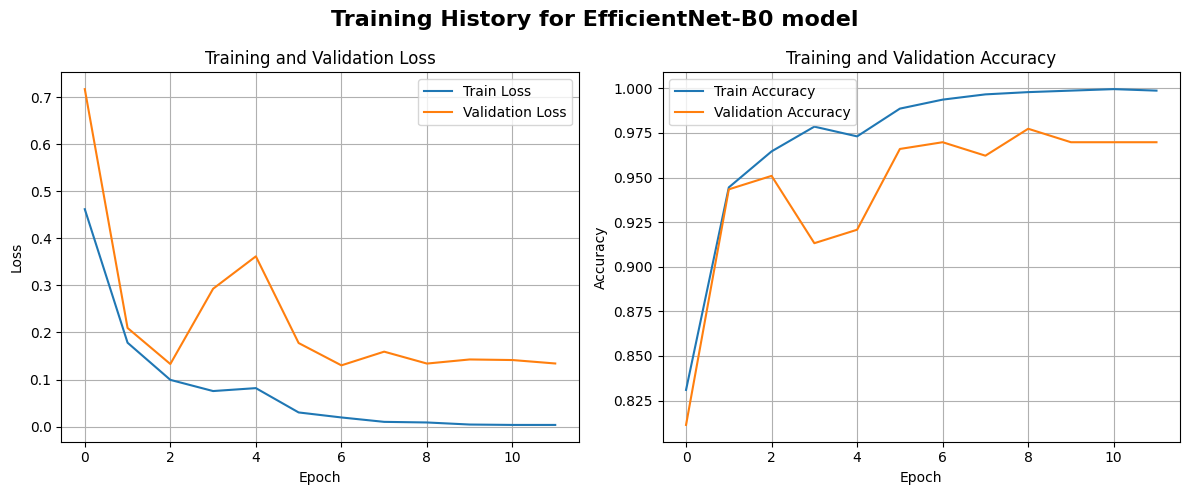

In [58]:
# Plotting training and validation loss
plt.figure(figsize=(12, 5))

plt.suptitle('Training History for EfficientNet-B0 model', fontsize=16, fontweight='bold')

plt.subplot(1, 2, 1)
plt.plot(history_eff.history['loss'], label='Train Loss')
plt.plot(history_eff.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history_eff.history['accuracy'], label='Train Accuracy')
plt.plot(history_eff.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

### Saving Model

In [59]:
model_eff.save("effnet.keras")

In [60]:
model_eff.save("my_model_effnet.keras")

In [61]:
model_eff = tf.keras.models.load_model("my_model_effnet.keras")

### Confusion Matrix

82/83 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

E0000 00:00:1752325909.114912      71 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752325909.279590      71 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


83/83 ━━━━━━━━━━━━━━━━━━━━ 18s 151ms/step


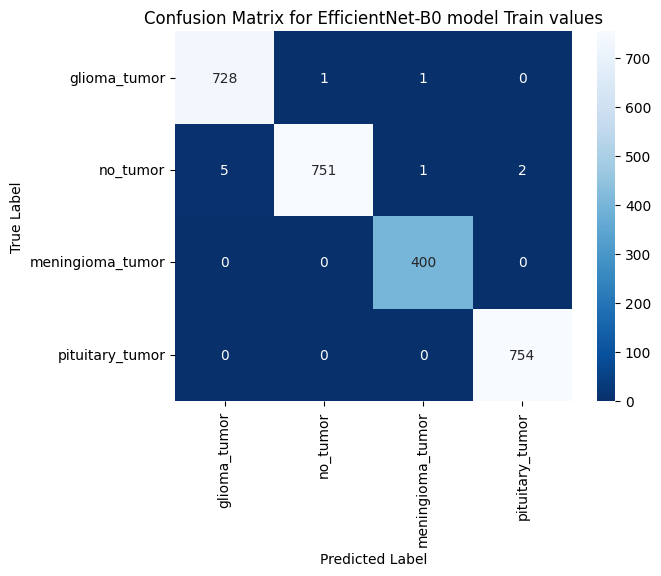

In [62]:
y_true = np.argmax(y_train, axis=1)
y_pred = np.argmax(model_eff.predict(X_train), axis=1) 

heatmap = sns.heatmap(confusion_matrix(y_true,y_pred), annot=True, fmt='d', cmap='Blues_r',
                      xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix for EfficientNet-B0 model Train values')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

E0000 00:00:1752325915.691247      73 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752325915.835363      73 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 501ms/step


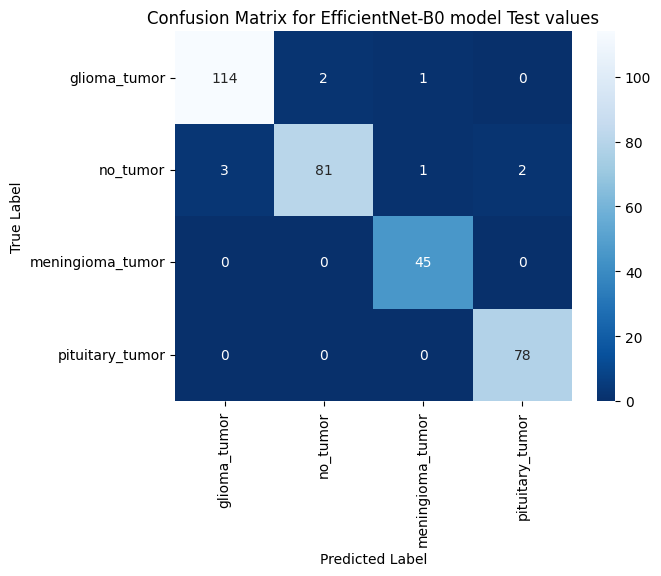

In [63]:
y_true_test = np.argmax(y_test, axis=1)
y_pred_test = np.argmax(model_eff.predict(X_test), axis=1) 

heatmap = sns.heatmap(confusion_matrix(y_true_test,y_pred_test), annot=True, fmt='d', cmap='Blues_r',
                      xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix for EfficientNet-B0 model Test values')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Classifiction Report

In [64]:
# 0 - Glioma Tumor
# 1 - No Tumor
# 2 - Meningioma Tumor
# 3 - Pituitary Tumor
print(classification_report(y_true_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       117
           1       0.98      0.93      0.95        87
           2       0.96      1.00      0.98        45
           3       0.97      1.00      0.99        78

    accuracy                           0.97       327
   macro avg       0.97      0.98      0.97       327
weighted avg       0.97      0.97      0.97       327



### Multiple Predictions

E0000 00:00:1752325922.961145      72 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752325923.103282      72 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752325923.235614      72 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


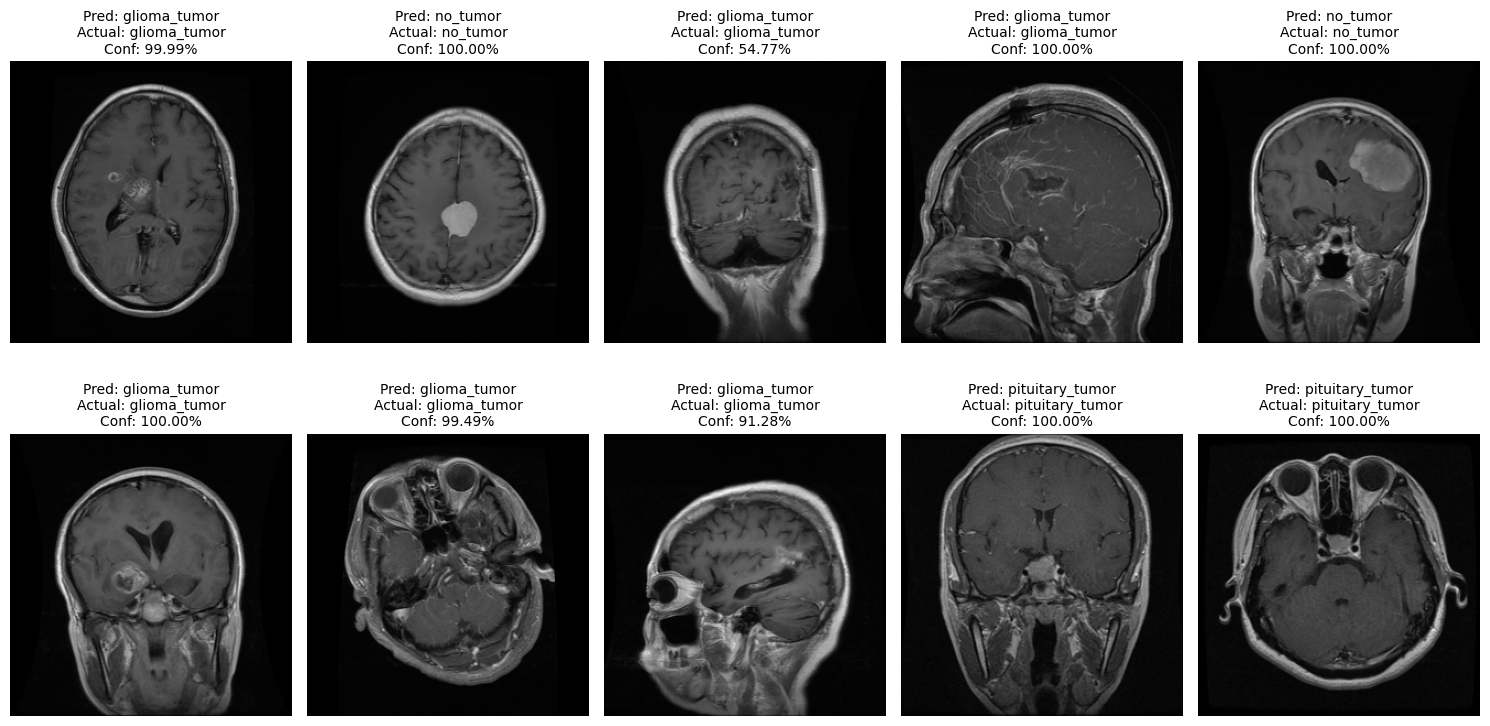


Image 1:
Predicted label: glioma_tumor
Actual label: glioma_tumor
Confidence: 99.99%

Image 2:
Predicted label: no_tumor
Actual label: no_tumor
Confidence: 100.00%

Image 3:
Predicted label: glioma_tumor
Actual label: glioma_tumor
Confidence: 54.77%

Image 4:
Predicted label: glioma_tumor
Actual label: glioma_tumor
Confidence: 100.00%

Image 5:
Predicted label: no_tumor
Actual label: no_tumor
Confidence: 100.00%

Image 6:
Predicted label: glioma_tumor
Actual label: glioma_tumor
Confidence: 100.00%

Image 7:
Predicted label: glioma_tumor
Actual label: glioma_tumor
Confidence: 99.49%

Image 8:
Predicted label: glioma_tumor
Actual label: glioma_tumor
Confidence: 91.28%

Image 9:
Predicted label: pituitary_tumor
Actual label: pituitary_tumor
Confidence: 100.00%

Image 10:
Predicted label: pituitary_tumor
Actual label: pituitary_tumor
Confidence: 100.00%


In [65]:
random_indexes = np.random.randint(0, len(X_test), 10)
random_imgs = X_test[random_indexes]
predictions = [model_eff.predict(random_img.reshape(1, 256, 256, 3)) for random_img in random_imgs]  # Reshape and preprocess the image

# Interpret the model's predictions
predicted_classes = [np.argmax(prediction) for prediction in predictions]  # Get the index of the class with the highest probability
predicted_labels = [labels[predicted_class] for predicted_class in predicted_classes]  # Convert class to label
confidences = [prediction[0][predicted_class] for prediction, predicted_class in zip(predictions, predicted_classes)]

actual_indexes = [y_test[random_index] for random_index in random_indexes]  # Get the one-hot encoded actual class
actual_classes = [np.argmax(actual_index) for actual_index in actual_indexes]
actual_labels = [labels[actual_class] for actual_class in actual_classes]

plt.figure(figsize=(15, 8))
for i in range(10):
    plt.subplot(2, 5, i + 1)  # 2 rows, 5 columns
    plt.imshow(random_imgs[i])
    plt.title(f"Pred: {predicted_labels[i]}\nActual: {actual_labels[i]}\nConf: {confidences[i]*100:.2f}%",
              fontsize=10, color='black')
    plt.axis('off')
plt.tight_layout()
plt.show()

for i in range(10):
    print(f"\nImage {i+1}:")
    print(f"\033[94mPredicted label: {predicted_labels[i]}\033[0m")
    print(f"\033[92mActual label: {actual_labels[i]}\033[0m")
    print(f"\033[93mConfidence: {confidences[i]*100:.2f}%\033[0m")